# Modifications Copyright (c) 2024 Advanced Micro Devices, Inc.
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
# THE SOFTWARE.

# Preparation

In [2]:
!pip install pandas
!pip install matplotlib

# Import libraries
import pandas as pd

from Utils import *
%matplotlib inline

### Global Parameters

In [8]:
# Specify the data path
datafile = '//mnt/beegfs/home/psamfass/ML/hipCollections/build/benchmarks/all_cg.csv'

baseline_datafile = '/mnt/beegfs/home/psamfass/cuCo_bench/a100/static_multimap_cg_8.csv'

output_keys_comparison = ['Key','Benchmark', 'Label', 'Distribution', 'MatchingRate', 'Multiplicity', \
                'Occupancy', 'GPU Time (sec)', 'Elem/s (elem/sec)']

output_keys = output_keys_comparison.copy()
output_keys.append("ProbingCGSize")

plot_baseline=True

['Key', 'Benchmark', 'Label', 'Distribution', 'MatchingRate', 'Multiplicity', 'Occupancy', 'GPU Time (sec)', 'Elem/s (elem/sec)', 'ProbingCGSize']


### Import Data

In [11]:
# Read csv file
rawdf = pd.read_csv(datafile)

# Filter out skipped tests
perfdf = rawdf[rawdf["Key"] == rawdf["Value"]].reset_index(drop=True)


# Add labels
perfdf['Label'] = perfdf["Key"]
perfdf.loc[perfdf['Distribution'].notnull(), 'Label'] += "_" + perfdf['Distribution']
perfdf['Label'] += '_CG'+perfdf["ProbingCGSize"].astype(str)

# Trim data frame for visualization
perfdf = perfdf[output_keys]


# Read csv file
rawdf_baseline = pd.read_csv(baseline_datafile)

# Filter out skipped tests
perfdf_baseline = rawdf_baseline[rawdf_baseline["Key"] == rawdf_baseline["Value"]].reset_index(drop=True)


# Add labels
perfdf_baseline['Label'] = perfdf_baseline["Key"]
perfdf_baseline.loc[perfdf_baseline['Distribution'].notnull(), 'Label'] += "_" + perfdf_baseline['Distribution']

# Trim data frame for visualization
perfdf_baseline = perfdf_baseline[output_keys_comparison]
perfdf_baseline.head()

,Key,Benchmark,Label,Distribution,MatchingRate,Multiplicity,Occupancy,GPU Time (sec),Elem/s (elem/sec)
0,I32,static_multimap_insert_uniform_multiplicity,I32_UNIFORM,UNIFORM,NaN,1.0,NaN,0.022061,4.532838e+09
1,I32,static_multimap_insert_uniform_multiplicity,I32_UNIFORM,UNIFORM,NaN,2.0,NaN,0.022149,4.514934e+09
2,I32,static_multimap_insert_uniform_multiplicity,I32_UNIFORM,UNIFORM,NaN,4.0,NaN,0.022376,4.468985e+09
3,I32,static_multimap_insert_uniform_multiplicity,I32_UNIFORM,UNIFORM,NaN,8.0,NaN,0.023200,4.310418e+09
4,I32,static_multimap_insert_uniform_multiplicity,I32_UNIFORM,UNIFORM,NaN,16.0,NaN,0.025213,3.966260e+09


# Visualization

### Visualization Parameters

In [12]:
# Get benchmark list
unique_bms = perfdf["Benchmark"].unique()
for it in unique_bms:
    print(it)

static_multimap_insert_uniform_multiplicity
static_multimap_insert_unique_occupancy
static_multimap_insert_gaussian_skew
static_multimap_retrieve_uniform_occupancy
static_multimap_retrieve_uniform_matching_rate
static_multimap_retrieve_uniform_multiplicity
static_multimap_query_uniform_occupancy
static_multimap_query_uniform_matching_rate
static_multimap_query_uniform_multiplicity
static_multimap_count_uniform_occupancy
static_multimap_count_uniform_matching_rate
static_multimap_count_uniform_multiplicity


### `insert` performance by varying key multiplicities
<ul>
<li>100'000'000 insertions</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.8</li>
<li>UNIFORM distribution</li>
</ul>

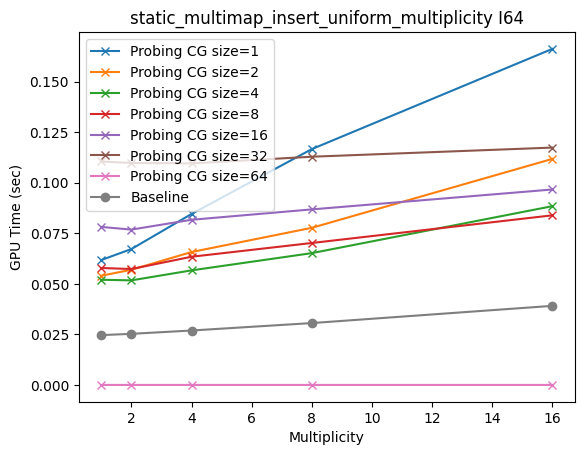

In [14]:
for bm in unique_bms:
    flag = "static_multimap_insert_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title("static_multimap_insert_uniform_multiplicity I64")
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()


### `insert` performance by varying occupancies
<ul>
<li>100'000'000 insertions</li>
<li>Fixed matching rate: 0.5</li>
</ul>

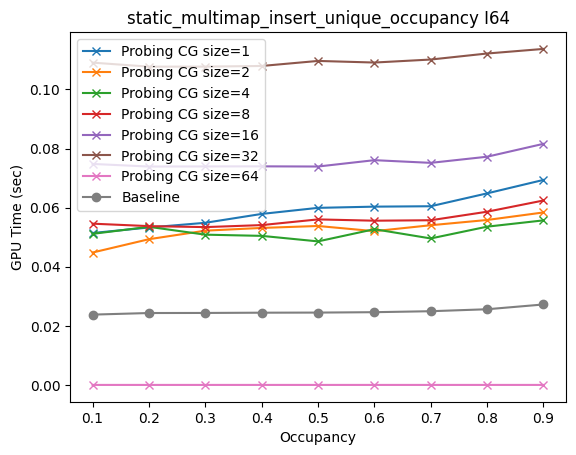

In [15]:
for bm in unique_bms:
    flag = "static_multimap_insert_unique_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")
          
          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()


### `count` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

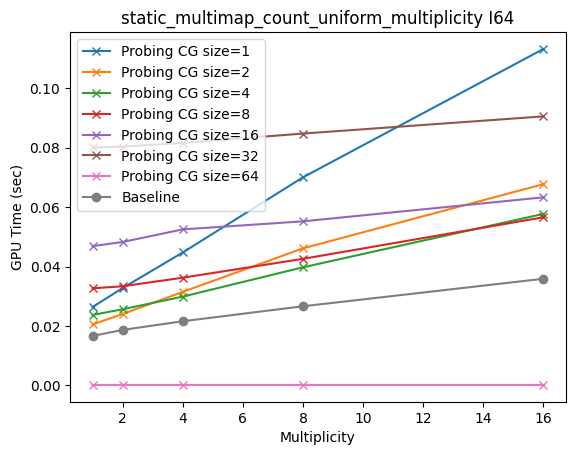

In [16]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `count` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

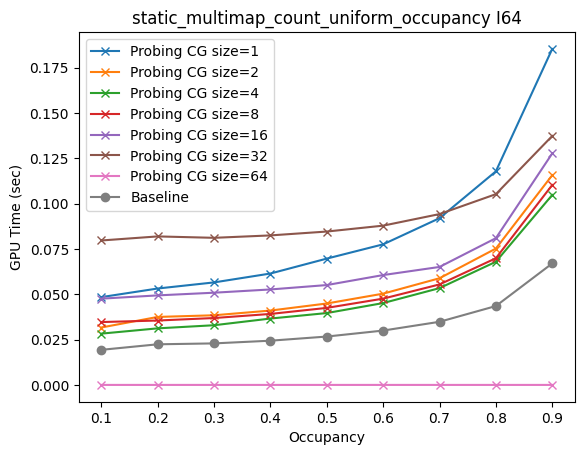

In [17]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `count` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed occupancy: 0.5</li>
</ul>

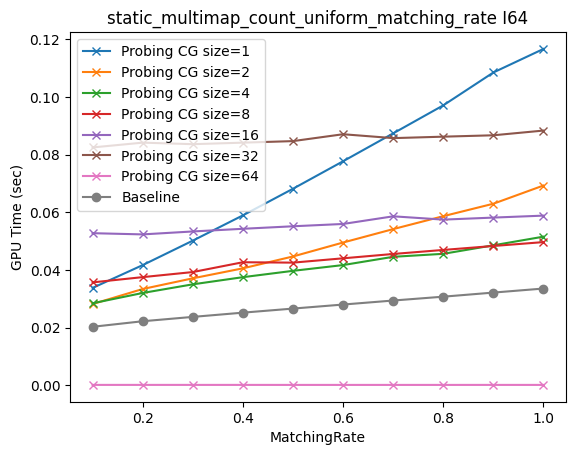

In [18]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_matching_rate" == bm
    x_param = "MatchingRate"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

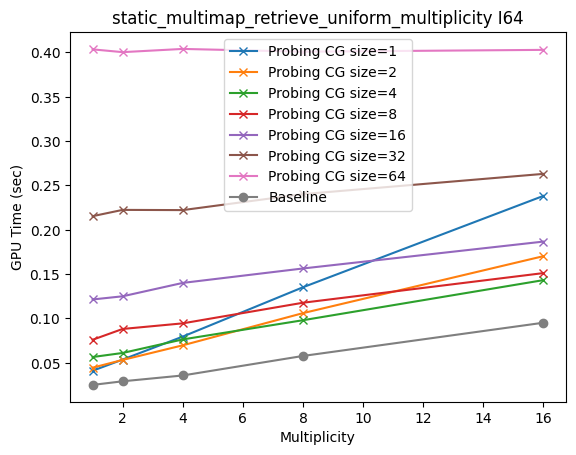

In [19]:
for bm in unique_bms:
    flag = "static_multimap_retrieve_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

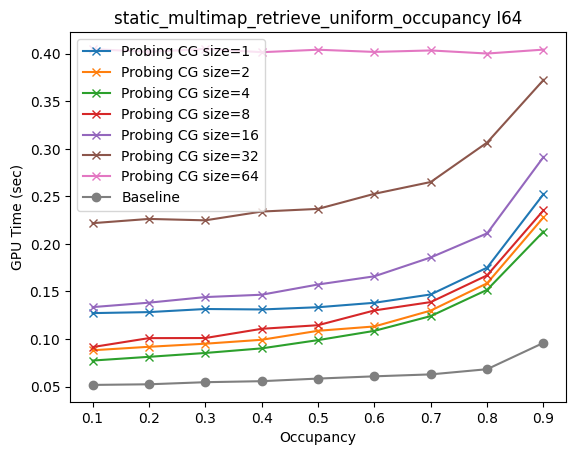

In [20]:
for bm in unique_bms:
    flag = "static_multimap_retrieve_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed occupancy: 0.5</li>
</ul>

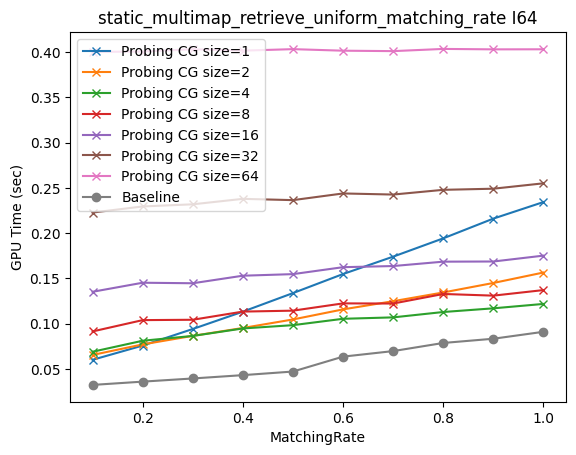

In [22]:
for bm in unique_bms:
    flag = "static_multimap_retrieve_uniform_matching_rate" == bm
    x_param = "MatchingRate"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `query` (`retrieve`  + `count`) performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

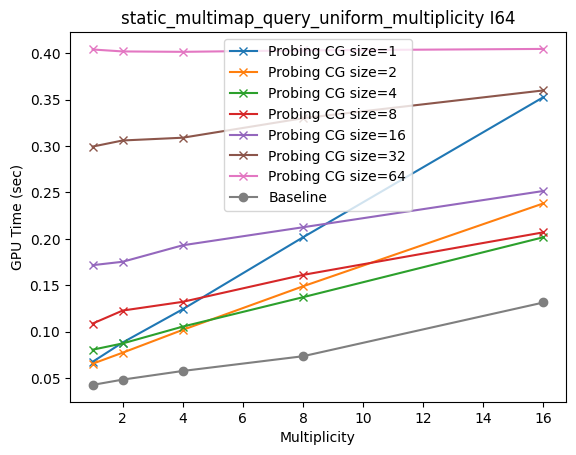

In [23]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"

    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")          

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `query` (`retrieve`  + `count`) performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

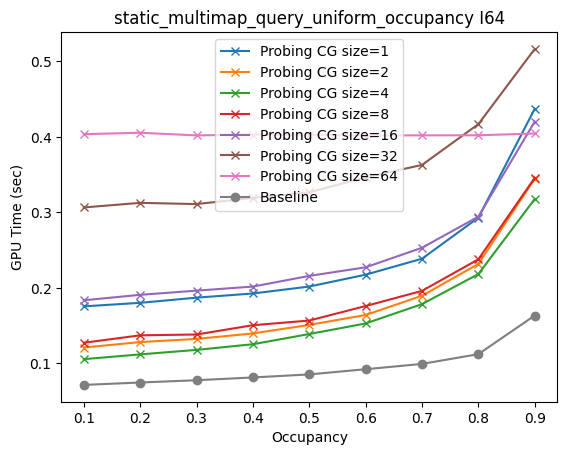

In [24]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")
        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `query` (`retrieve`  + `count`) performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

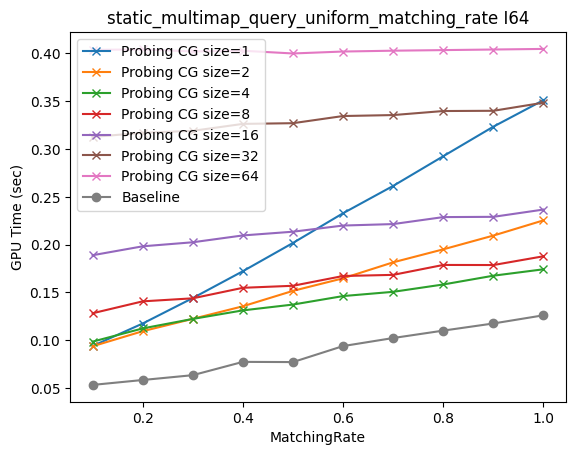

In [25]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_matching_rate" == bm
    x_param = "MatchingRate"
    key_type = "I32"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

        if plot_baseline:
          tmpdf_base = perfdf_baseline[(perfdf_baseline["Benchmark"] == bm) & (perfdf_baseline["Key"]==key_type)]
          plt.plot(tmpdf_base[x_param], tmpdf_base["GPU Time (sec)"], label="Baseline", marker="o")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()